# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [1]:
!pip pandas 

ERROR: unknown command "pandas"



---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [ ]:
# TODO
#data size(xem dòng và cột)
print("data size: ", df.shape)


In [ ]:
#xem thông tin tổng quan(xem dòng và cột)
df.info 

In [ ]:
#column names(xem tên các cột)
print("columns: ",df.columns)

In [ ]:
#data types(xem kiểu data)
df.dtypes

## A.2. Missing values & Duplicate data

In [ ]:
# TODO
#Missing values (giá trị bị thiếu)
df.isnull().sum()


In [ ]:
#duplicate data(data trùng)
print("duplicate data:", df.duplicated().sum())

#điếm trùng
print("duplicate data: ",df.duplicated().count())

## A.3. Invalid values

In [ ]:
# TODO
# Invalid values(các giá trị hợp lệ không)unique
print(df['children'].unique())

## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [ ]:
# TODO
df['bmi_group']

---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [ ]:
# TODO
print("mean: ",df['age'].mean())
print("median: ", df['age'].median())
print("mode: ", df['age'].mode())

## Group 2 — Dispersion

In [ ]:
# TODO
print(df['age'].max() - df['age'].min())
#phương sai(var)
print(df['age'].var())
#độ lệch chuẩn(std)
print(df['age'].std())

## Group 3 — Location and Shape

In [ ]:
# TODO
#vị trí(location) skew() chọn độ lệch
print("skew: ", df['age'].skew())
#độ chọn, kurt()
print("kurt: ", df['age'].kurt())


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

In [4]:
# TODO
# So sánh chi phí trung bình
avg_smoker = df[df['smoker'] == 'yes']['charges'].mean()
avg_non_smoker = df[df['smoker'] == 'no']['charges'].mean()
ratio = avg_smoker / avg_non_smoker
print("Smoker trả cao hơn:", ratio, "lần")

# Phân tích theo vùng
region_ratio = df.groupby(['region','smoker'])['charges'].mean().unstack()
region_ratio['ratio'] = region_ratio['yes'] / region_ratio['no']
print(region_ratio)


Smoker trả cao hơn: 3.800001458298317 lần
smoker              no           yes     ratio
region                                        
northeast  9165.531672  29673.536473  3.237514
northwest  8556.463715  30192.003182  3.528561
southeast  8032.216309  34844.996824  4.338155
southwest  8019.284513  32269.063494  4.023933


## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

In [ ]:
# TODO
# Nhóm hút thuốc
smoker_group = df[df['smoker'] == 'yes']
corr_smoker, _ = pearsonr(smoker_group['bmi'], smoker_group['charges'])
print("Correlation (Smoker):", corr_smoker)


Correlation (Smoker): 0.8064806070155405


In [12]:
# Nhóm không hút thuốc
non_smoker_group = df[df['smoker'] == 'no']
corr_non_smoker, _ = pearsonr(non_smoker_group['bmi'], non_smoker_group['charges'])

print("Correlation (Non-Smoker):", corr_non_smoker)

Correlation (Non-Smoker): 0.08403654312833271


## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [5]:
# TODO
region_mean = df.groupby('region')['charges'].mean().sort_values(ascending=False)
print(region_mean)


region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


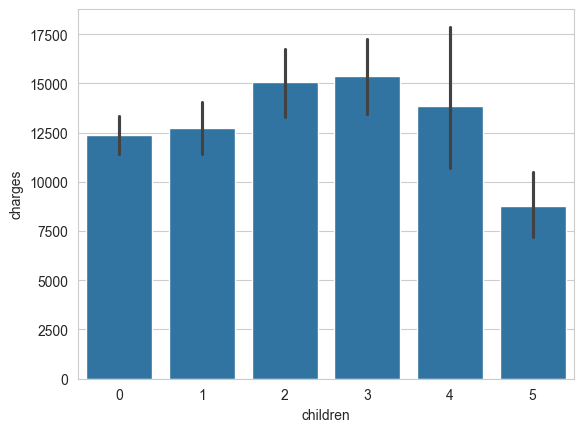

In [6]:
# TODO
children_mean = df.groupby('children')['charges'].mean()
print(children_mean)


sns.barplot(x='children', y='charges', data=df)
plt.show()


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [8]:
# TODO
from scipy.stats import pearsonr
corr, _ = pearsonr(df['age'], df['charges'])
print("Correlation:", corr)


Correlation: 0.29900819333064754


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*